# Readout Raw Data

In this notebook, you'll learn how to access the raw time traces of the readout integration unit for both UHFQA and SHFQA, which may be used to optimize the readout fidelity when designing matched filter functions for the readout integration weights.

## 0. Python Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)

# LabOne Q:
from laboneq.simple import *

## 1. Define Device Setup and Calibration

### 1.1 Device Setup

The device setup we use here contains either an UHFQA or a SHFQC in order to demonstrate raw readout trace access for the quantum analyser channels on those instruments.

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 1

# generate the device setup and the qubit objects using a helper function - remove either the UHFQA or the SHFQC to make this work
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "dio": "DEV2001",
            "options": None,
        }
    ],
    # uhfqa=[{"serial": "DEV2001", "readout_multiplex": 6}],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    include_flux_lines=False,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_fixed_qubit_setup",
)

q0 = qubits[0]

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a LabOne Q session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 11:25:25.078] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 11:25:25.079] INFO    VERSION: laboneq 26.4.0
[2026.06.26 11:25:25.080] INFO    Connecting to data server at localhost:8004
[2026.06.26 11:25:25.081] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 11:25:25.082] INFO    Configuring the device setup
[2026.06.26 11:25:25.096] INFO    The device setup is configured


## 2. Readout raw time traces with a UHFQA or an SHFQA

readout raw integrsation traces for two situations - qubit in groundstate and qubit in excited state

difference in raw traces can be used for readout weight optimisation

### 2.1 Define the Experiment

In [4]:
# how many averages
average_exponent = 10  # used for 2^n averages, n=average_exponent, maximum: n = 19

## define pulses used for experiment

# qubit drive - needs to be calibrated pulse to bring qubit into excited state
x180 = pulse_library.gaussian(uid="x180", length=100e-9, amplitude=1.0)
# qubit readout pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=100e-9, amplitude=1.0)
# readout integration weights - here simple square pulse, i.e. same weights at all times
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=200e-9, amplitude=1.0
)

In [5]:
# Create Experiment - qubit remains in ground state
exp_0 = Experiment(
    uid="Optimal weights",
    signals=[
        ExperimentSignal(uid="drive", map_to=q0.signals["drive"]),
        ExperimentSignal(uid="measure", map_to=q0.signals["measure"]),
        ExperimentSignal(uid="acquire", map_to=q0.signals["acquire"]),
    ],
)
# outer averaging loop - real-time averaging of raw data
with exp_0.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.RAW,
):
    # qubit readout and data acquisition
    with exp_0.section(uid="qubit_readout"):
        exp_0.play(signal="measure", pulse=readout_pulse)
        exp_0.acquire(
            signal="acquire", handle="ac_0", kernel=readout_weighting_function
        )
    # relax time after readout - for signal processing and qubit relaxation to ground state
    with exp_0.section(uid="relax", length=1e-6):
        exp_0.reserve(signal="measure")

In [6]:
# Create Experiment - qubit gets excited into excited state
exp_1 = Experiment(
    uid="Optimal weights",
    signals=[
        ExperimentSignal(uid="drive", map_to=q0.signals["drive"]),
        ExperimentSignal(uid="measure", map_to=q0.signals["measure"]),
        ExperimentSignal(uid="acquire", map_to=q0.signals["acquire"]),
    ],
)
# outer averaging loop - real-time averaging of raw data
with exp_1.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.RAW,
):
    # qubit excitation section - drive qubit into excited state
    with exp_1.section(uid="qubit_excitation"):
        exp_1.play(signal="drive", pulse=x180)
    # qubit readout and data acquisition
    with exp_1.section(uid="qubit_readout"):
        exp_1.reserve(signal="drive")
        exp_1.play(signal="measure", pulse=readout_pulse)
        exp_1.acquire(
            signal="acquire", handle="ac_1", kernel=readout_weighting_function
        )
    # relax time after readout - for signal processing and qubit relaxation to ground state
    with exp_1.section(uid="relax", length=1e-6):
        exp_1.reserve(signal="measure")

In [7]:
# run the first experiment and access the data
results_0 = session.run(exp_0)
raw_0 = results_0.get_data("ac_0")

# run the second experiment and access the data
results_1 = session.run(exp_1)
raw_1 = results_1.get_data("ac_1")

[2026.06.26 11:25:25.118] INFO    Starting LabOne Q Compiler run...
[2026.06.26 11:25:25.123] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.26 11:25:25.124] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.26 11:25:25.124] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.26 11:25:25.125] INFO    Schedule completed. [0.001 s]
[2026.06.26 11:25:25.132] INFO    Code generation completed for all AWGs. [0.007 s]
[2026.06.26 11:25:25.132] INFO    Completed compilation step 1 of 1. [0.008 s]
[2026.06.26 11:25:25.136] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 11:25:25.136] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 11:25:25.136] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 11:25:25.136] INFO      shfqc_0        0          7            0          

### 2.2 Plot the results

Text(0, 0.5, 'Amplitude (a.u.)')

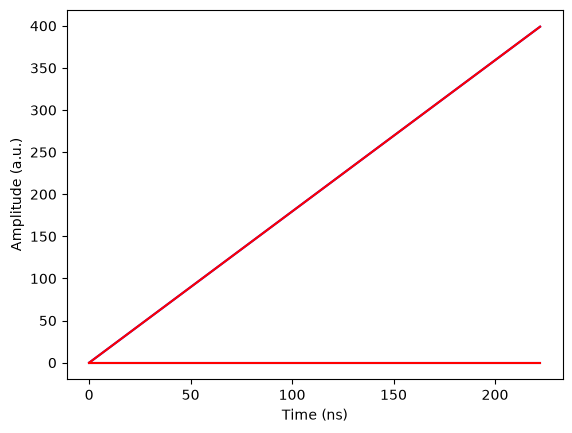

In [8]:
time = np.linspace(0, len(raw_0) / 1.8, len(raw_0))
# for groundstate
plt.plot(time, np.real(raw_0), "b")
plt.plot(time, np.imag(raw_0), "-b")
# for excited state
plt.plot(time, np.real(raw_1), "r")
plt.plot(time, np.imag(raw_1), "-r")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (a.u.)")